# AssureX Claim Engine — Dataset Audit & Preprocessing

This notebook validates the warranty-claim dataset, checks class/split balance, inspects missing data, engineers date-based features, and defines a leakage-conscious feature set for the Python classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path
import pandas as pd
import numpy as np

DATA_NAME = "assurex_nigeria_warranty_claims_v2.csv"
CANDIDATES = [
    Path('/mnt/data') / DATA_NAME,
    Path(DATA_NAME),
    Path('../data') / DATA_NAME,
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Place {DATA_NAME} beside the notebook or in ../data/")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")


Loaded: assurex_nigeria_warranty_claims_v2.csv
Shape: (2400, 57)


## 1. Dataset structure

In [2]:
display(df.head(3))
print('Columns:', len(df.columns))
print(df.dtypes.value_counts())

,claim_id,region_zone,state,city,customer_type,seller_type,purchase_channel,product_category,brand,model_family,...,reporting_delay_days,policy_reporting_deadline_days,statutory_3_month_window,requested_remedy,claim_amount_ngn,document_completeness_score,claim_channel,claim_class,split,provenance_ref
0,NG-WC-00001,South East,Abia,Aba,Home Office,Authorized Dealer,Physical Store,Bluetooth Speaker,Oraimo,Boom series,...,42,30,False,Repair,5000,0.5,Authorized service centre,Manual Review Required,validation,PV-00001
1,NG-WC-00974,North East,Taraba,Jalingo,Individual,Authorized Dealer,Physical Store,Refrigerator,LG,Inverter Refrigerator,...,40,14,False,Repair,949000,1.0,Online support form,Likely Invalid,validation,PV-00974
2,NG-WC-01945,North Central,FCT,Abuja,Individual,Authorized Dealer,Physical Store,Solar Inverter,Felicity Solar,IVPS / IVGM selected series,...,0,21,False,Repair or replacement,2947000,1.0,Marketplace support portal,Likely Valid,test,PV-01945


Columns: 57
str        37
bool       11
int64       8
float64     1
Name: count, dtype: int64


## 2. Required target and split balance

The SRS requires Valid, Invalid, and Manual Review classes, with clean train/validation/test separation.

In [3]:
print('Class counts:')
display(df['claim_class'].value_counts().rename('count').to_frame())
print('Split counts:')
display(df['split'].value_counts().rename('count').to_frame())
print('Class by split:')
display(pd.crosstab(df['split'], df['claim_class']))

Class counts:


,count
claim_class,
Manual Review Required,800
Likely Invalid,800
Likely Valid,800


Split counts:


,count
split,
train,1680
validation,360
test,360


Class by split:


claim_class,Likely Invalid,Likely Valid,Manual Review Required
split,,,
test,120,120,120
train,560,560,560
validation,120,120,120


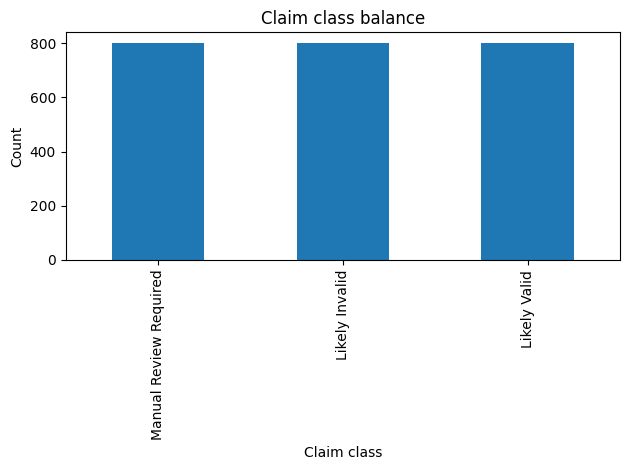

In [4]:
ax = df['claim_class'].value_counts().plot(kind='bar', title='Claim class balance')
ax.set_xlabel('Claim class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Missing-data audit

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
display(missing.head(20))

,missing_count,missing_pct
duplicate_claim_indicator,2227,92.79
serial_evidence_type,128,5.33
purchase_document_type,52,2.17


## 4. Identifier and leakage audit

Unique IDs, provenance fields, the dataset split, and the target itself must never be model inputs. Business-rule outputs are also excluded so the ML model remains meaningfully separate from the warranty rule engine.

In [7]:
for c in ['claim_id','provenance_ref','policy_code','model_family','brand','state','city']:
    print(f'{c:25s} unique={df[c].nunique(dropna=False)}')

claim_id                  unique=2400
provenance_ref            unique=2400
policy_code               unique=13
model_family              unique=23
brand                     unique=10
state                     unique=28
city                      unique=30


In [8]:
def engineer_features(frame):
    frame = frame.copy()
    for col in ['manufacture_date', 'purchase_date', 'fault_date', 'claim_date']:
        frame[col] = pd.to_datetime(frame[col], errors='coerce')
    frame['manufacture_to_purchase_days'] = (frame['purchase_date'] - frame['manufacture_date']).dt.days
    frame['purchase_to_fault_days'] = (frame['fault_date'] - frame['purchase_date']).dt.days
    frame['fault_to_claim_days'] = (frame['claim_date'] - frame['fault_date']).dt.days
    frame['claim_month'] = frame['claim_date'].dt.month
    return frame

# Keep business-rule outputs independent of the ML classifier.
# This avoids letting the Python model merely learn the final rule-engine result.
EXCLUDED_COLUMNS = {
    'claim_id', 'provenance_ref', 'split', 'claim_class',
    'manufacture_date', 'purchase_date', 'fault_date', 'claim_date', 'warranty_expiry_date',
    'fault_description', 'claim_narrative',
    'warranty_status', 'official_channel_status', 'fault_coverage_status',
    'serial_match_status', 'proof_of_purchase_status', 'duplicate_claim_indicator',
    'contradiction_flag', 'unauthorized_repair_flag', 'tamper_flag',
    'reported_within_return_window', 'statutory_3_month_window'
}

df_model = engineer_features(df)
FEATURE_COLUMNS = [c for c in df_model.columns if c not in EXCLUDED_COLUMNS]
X = df_model[FEATURE_COLUMNS]
y = df_model['claim_class']


In [9]:
print(f'Features retained: {len(FEATURE_COLUMNS)}')
print(f'Excluded columns: {len(EXCLUDED_COLUMNS)}')
print('\nRetained features:')
print(FEATURE_COLUMNS)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
print(f'\nNumeric features: {len(num_cols)}')
print(f'Categorical / boolean features: {len(cat_cols)}')

Features retained: 39
Excluded columns: 22

Retained features:
['region_zone', 'state', 'city', 'customer_type', 'seller_type', 'purchase_channel', 'product_category', 'brand', 'model_family', 'purchase_price_ngn', 'payment_method', 'warranty_provider', 'policy_code', 'warranty_start_basis', 'warranty_months', 'days_from_purchase_to_claim', 'fault_category', 'damage_cause', 'receipt_available', 'purchase_document_type', 'warranty_card_available', 'serial_or_imei_available', 'serial_evidence_type', 'product_photo_available', 'repair_report_available', 'fault_evidence_type', 'prior_repairs', 'prior_repair_authorized', 'return_window_days', 'reporting_delay_days', 'policy_reporting_deadline_days', 'requested_remedy', 'claim_amount_ngn', 'document_completeness_score', 'claim_channel', 'manufacture_to_purchase_days', 'purchase_to_fault_days', 'fault_to_claim_days', 'claim_month']

Numeric features: 13
Categorical / boolean features: 26


## 5. Data-quality conclusions

- The dataset contains 2,400 records, exceeding the 1,500-record minimum.
- The three target classes are balanced.
- The supplied train/validation/test split is balanced and should be preserved.
- `claim_id`, `provenance_ref`, `split`, and target-related fields are excluded from training.
- Rule-engine outcome fields are kept outside the Python classifier so later rule validation remains an independent decision layer.
- Free-text narrative fields are intentionally excluded from this structured-model baseline. They can be explored later as a separate NLP experiment without contaminating the core tabular benchmark.